This notebook shows all inputs needed for the calculation of the EBL,
and how to calculate the outputs.

Inputs for the EBL caused by the stellar population:
- Stellar synthetic spectra
- Stellar formation rate
- Metallicity evolution
- Dust absorption model
- Dust reemission template (and possible parameters associated with the template)

Inputs for the EBL caused by the intrahalo light (Stars expelled from their galaxies):
- A_ihl
- alpha

# Imports

In [1]:
# Check that the working directory is correct for the paths
import os

if os.path.basename(os.getcwd()) == 'scripts' or os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir("..")

# If the directory for outputs is not present, create it.
if not os.path.exists("outputs/"):
    os.makedirs("outputs/")

In [2]:
import yaml
import psutil
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import c
from scipy.interpolate import UnivariateSpline, RegularGridInterpolator

import ebl_codes.dust_absorption_models as dust_abs
from ebl_codes.EBL_class import EBL_model

# Data that I have but it is not mine so please request access?
from data.cb_measurs.import_cb_measurs import import_cb_data
from data.emissivity_measurs.emissivity_read_data import emissivity_data
from data.sfr_measurs.sfr_read import *
from data.metallicity_measurs.import_metall import import_met_data

# If we want to compare our results to previous calculations of the EBL, we load ebltable
# from https://github.com/me-manu/ebltable
from ebltable.ebl_from_model import EBL

Module hmf not loaded


### Some matplotlib values that I like for my graphs
Please feel free to change these (but I think they are cool)

In [3]:
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['axes.labelsize'] = 20
plt.rc('font', size=20)
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('legend', fontsize=18)
plt.rc('figure', titlesize=17)
plt.rc('xtick', top=True, direction='in')
plt.rc('ytick', right=True, direction='in')
plt.rc('xtick.major', size=7, width=1.5, top=True)
plt.rc('ytick.major', size=7, width=1.5, right=True)
plt.rc('xtick.minor', size=4, width=1)
plt.rc('ytick.minor', size=4, width=1)

In [4]:
# Some arrays to distinguish different models in the next plots
models = ['solid', 'dashed', 'dotted', 'dashdot']
colors = ['b', 'r', 'g', 'orange', 'grey', 'purple', 'k', 'cyan', 'brown']

linstyles_ssp = ['solid', '--', 'dotted', '-.']

markers = ['.', 'x', '+', '*', '^', '>', '<']
color_ssp = ['b', 'orange', 'k', 'r', 'green', 'grey', 'limegreen', 'purple', 'brown']

# Configuration file reading and data input/output

In [5]:
# Directory where we have the yaml file that has the inputs for our model
# If you want to save figures, it's very useful to use this directory to save them
# (i.e. plt.savefig(input_file_dir + NAME_FIG.pdf, bbox_inches='tight'))

input_file_dir = ('notebooks/')
# input_file_dir = ('scripts/input_files/')

In [6]:
# Configuration file reading and data input/output
def read_config_file(ConfigFile):
    with open(ConfigFile, 'r') as stream:
        try:
            parsed_yaml = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return parsed_yaml

# We initialize the class with the input file
config_data = read_config_file(input_file_dir + 'input_example.yml')
# config_data = read_config_file(input_file_dir + 'input_dust_reem.yml')
ebl_class = EBL_model.input_yaml_data_into_class(config_data, log_prints=True)

/home/saraporras/PycharmProjects/EBL_calculation/ebl_codes/EBL_class.py:154: RuntimeWarning: divide by zero encountered in log10
  tt = np.log10(self._cosmo.lookback_time(
/home/saraporras/PycharmProjects/EBL_calculation/ebl_codes/EBL_class.py:161: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._z_array),
2024-11-25 15:41:02 - INFO - 0.21s: Initialize cubes: end


## Inputs in the config file
List of inputs in the config file and its definitions.

First, general ones that need to appear for the correct funtioning of the code:

**COSMOLOGY CONSTANTS (flat LCDM assumed)**
```
cosmology_params:
  cosmo: [0.7, 0.3, 0.7] # [h_0, omega_matter, omega_L]
  omegaBar: 0.0453 # omega baryons of our model (this example = 0.0222/0.7**2.)
```
> These four parameters $h_0$, $\omega_{matter}$, $\omega_{\lambda}$ and $\omega_{baryons}$ are input in the class `FlatLambdaCDM` of `astropy.cosmology`. They can be changed, but beware because if you want to compare them to data: in order to calculate data, a cosmological model is assumed (for most observations). Altering the cosmological model might make it impossible (or wrong) to compare the output model with observational data.

**WAVELENGTH ARRAY FOR EBL [microns]**
```
wavelength_array:
  lfsteps: 700
  lmax: 1e5
  lmin: 1e-2
```
> Wavelength array where to calculate the EBL intensities and emissivities. They have to be given in microns. This example covers both the optical and infrared parts of the electromagnetic spectrum.

**REDSHIFT ARRAY FOR EBL**
```
redshift_array:
  zmin: 0.
  zmax: 10.0
  zsteps: 100
```
> This is the redshift array where the emissivities and EBL will be avaible as outputs. This does not denote the integration limit at high redshift. That one is given by the next parameter:
```
z_intmax: 40.0
```
> This is $z_{max}$ in Eq.(B1) in the paper based on this code, its physical meaning is the maximum reshift ar which the . I reccomend to not change this value.

**NUMBER OF INTEGRATION STEPS**
```
t_intsteps: 201
```
> Same as before, this number is appropiate for sampling the integral kernels.

**PRINT THE LOGS OF THE PROGRAM**

```
log_prints: True
```
> Finally, the possibility of having the program spit all the verbose or silently run. Change this parameter at any point in your program to decide whether you want detailed information about the processes happening or you would prefer the calculations to be silent.

# Stellar contribution to the EBL
We say stellar, but really any contribution that has luminosities tabulated can be input and calculate its EBL intensity.

For each of the models we have more inputs in the config file.

For and example of an SSP config file, we can have:
```
ssp_example:
    name: 'Our model'
    
    ssp:
        path_SSP: data/ssp_synthetic_spectra/starburst99/kroupa_padova/
        ssp_type: SB99
        file_name: /kroupa_
        ignore_rows: 6
    
    dust_abs_models: finke2022_2
    dust_abs_params:
        params_ab18: [ 1.52, 0.35, 4.12, 5.89]
    
    metall_formula: 'lambda zz, args :10 ** (args[0] - args[1] * zz ** args[2]) * args[3]'
    metall_params:[ -0.147, 0.207, 0.819, 0.02]
    
    sfr_formula: 'lambda x, ci : ci[0] * (1 + x)**ci[1] / (1 + ((1+x)/ci[2])**ci[3])'
    sfr_params: [ 0.0150, 2.254, 3.347, 6.56]
    
    dust_reem: True
    dust_reem_params:
          library: chary2001
          file_path: 'data/ssp_synthetic_spectra/chary2001/chary_elbaz.fits'
          f_tir: 9.69
          wv_reem_min: 5.45  #[microns]
```
We are going to describe each of these in the next cells, explaining all the inputs that appear in this config example.

## SSP synthetic spectra - input for stellar EBL contribution
A simple stellar population (SSP) is defined as a group of stars born from the same gas cloud, which then evolve with no further star formation. The birth of the SSP lasts for megayears, so for cosmological purposes it can be assumed to be instantaneous. The stars in an SSP are assumed to share the same metallicity and age.

For this EBL calculation we input synthetic stellar spectra from SSPs. The spectra have to depend on wavelength, age of the population and (optionally) metallicity.

There are two ways of inputting the spectra. The first one is with our trustworthy config file. There are three available
```
ssp:
    path_SSP: data/ssp_synthetic_spectra/starburst99/kroupa_padova/
    ssp_type: SB99
    file_name: /kroupa_
    ignore_rows: 6
    total_stellar_mass: 6
```
Depending on `ssp_type` different 


The second way of inputting the luminosities is by providing an spline that provides luminosities. It has to be a specific object, specifically a ```scipy.RegularGridInterpolator``` with three input values:
- $log_{10}(freq[Hz])$ - array with the frequencies associated with wavelength.
- $log_{10}(age[years])$ - array with the logarithm of the age of the stellar population.
- $log_{10}(Z)$ - array with the metallicities of the SSP.

With the values of the spline given by a 3D cube with the values of the SSP luminosities $log_{10}(L_{\nu}[erg/s/Hz/M_\odot])$. Usually simulation scripts output the luminosities $L_{\lambda}$, so a unit conversion migth be necessary following the relation $\lambda L_{\lambda} = \nu L_{\nu}$.



SSP model:  Our model


KeyError: 'path_SSP'

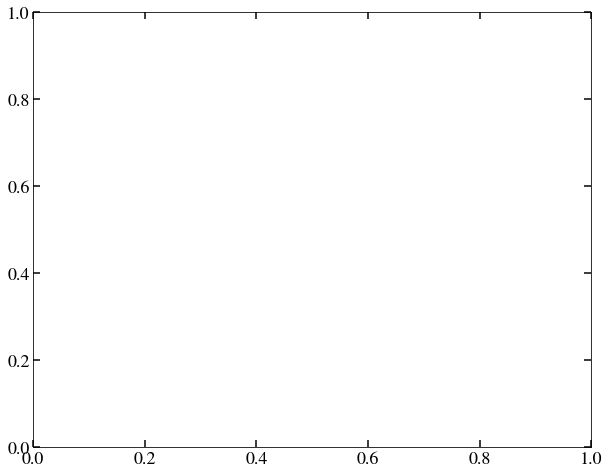

In [7]:
fig_ssp, ax_ssp = plt.subplots(figsize=(10, 8))

xx_amstrongs = np.logspace(2, 6, 2000)

previous_ssp = []
labels_ssp1 = []
handles_ssp1 = []
labels_ssp2 = []
handles_ssp2 = []

# Plot the synthetic spectra populations
for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ebl_class.read_SSP_file(config_data['ssp_models'][key]['path_SSP'],
                            config_data['ssp_models'][key]['ssp_type'],
                            pop_filename=config_data['ssp_models'][key]['file_name'],
                            cut_popstar=config_data['ssp_models'][key]['cut_popstar'])

    if config_data['ssp_models'][key]['path_SSP'] not in previous_ssp:
        previous_ssp.append(config_data['ssp_models'][key]['path_SSP'])
        labels_ssp2.append(config_data['ssp_models'][key]['path_SSP'].replace(
                'data/ssp_synthetic_spectra/', ''))
        handles_ssp2.append(
            plt.Line2D([], [], linewidth=2,
                       linestyle=linstyles_ssp[len(previous_ssp) - 1],
                       color='k'))
        
        list_met = ebl_class._ssp_metall
        list_met = np.sort(list_met)
        
        for n_met, met in enumerate(list_met):
            for i, age in enumerate([6.0, 6.5, 7.5, 8., 8.5, 9., 10.]):
                ax_ssp.plot(
                    xx_amstrongs,
                    ebl_class.ssp_lumin_spline(
                        xi=(
                            np.log10(c.value / xx_amstrongs * 1e10),
                            age, np.log10(met)),
                    ),
                    linestyle=linstyles_ssp[len(previous_ssp) - 1],
                    color=color_ssp[i],
                    alpha=float(n_met) / len(list_met) * 1.1
                )
                if n_met == 0 and len(previous_ssp) == 1:
                    labels_ssp1.append(age)
                    handles_ssp1.append(
                        plt.Line2D([], [], linewidth=2, linestyle='-',
                                   color=color_ssp[i]))

legend11 = plt.legend(handles_ssp1, labels_ssp1,
                      loc=1,
                      title=r'Age (log$_{10}$(years))')
legend22 = plt.legend(handles_ssp2, labels_ssp2,
                      loc=4,
                      )
ax_ssp.add_artist(legend11)
ax_ssp.add_artist(legend22)

plt.xscale('log')

plt.title('More transparency, less metallicity')

# plt.ylim(0., 30.)

plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel(r'log$_{10}$(L$_{\lambda}$ '  # /Lsun '
           r'[erg s$^{-1}$ $\mathrm{\AA}^{-1}$ M$_{\odot}^{-1}$])')

## Dust absorption models
We provide some analytical models of dust absorption.

| Wavelength dependence | Model reference | Link |
| :-:  | :-:  | :-:  |
| kneiske2002 | Gaussian | .843 |
| razzaque2009 | ProbDistribution | Accuracy |
| dust_att_finke2 | Gaussian | .843 |


| Redshift dependence | Model reference | Link |
| :-: | :-: | :-: |
| abdollahi2018 | Gaussian | .843 |

Special combined cases:

| Name | Wavelength dependence | Redshift dependence |
| :-: | :-: | :-: |
| finke2022 | razzaque2009 | abdollahi2018 |
| finke2022_2 | dust_att_finke2 | abdollahi2018 |

In [ ]:
import os

if os.path.basename(os.getcwd()) == 'scripts' or os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir("..")
import ebl_codes.dust_absorption_models as dust_abs
import numpy as np
import matplotlib.pyplot as plt

x_lambda = np.logspace(-2, 1, num=5000)
# x_zetas = np.linspace(1e-6, 6, num=7)
x_zetas = np.array([0, 2, 4, 6])

fig, ax0 = plt.subplots(figsize=(8, 8))
color = []

for ni, ii in enumerate(x_zetas):
    if ni == 0:
        color.append( plt.cm.CMRmap(ni / float(len(x_zetas))))
        plt.plot(x_lambda, 10 ** dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['finke2022']),
                 ls='-', c=color[ni], label='Finke2022 model 1')
        plt.plot(x_lambda, 10**dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['finke2022_2']),
                 ls='--', c=color[ni], label='Finke2022 model 2')
    
    else:
        color.append( plt.cm.CMRmap(ni / float(len(x_zetas))))
        plt.plot(x_lambda, 10 ** dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['finke2022']),
                 ls='-', c=color[ni])
        plt.plot(x_lambda, 10**dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['finke2022_2']),
                 ls='--', c=color[ni])

plt.plot(x_lambda, 10 ** dust_abs.kneiske2002(x_lambda, dust_params=[]),
         'limegreen',label='Kneiske2002', ls=':', lw=2)


plt.ylabel('Escape fraction of photons')
plt.xlabel(r'Wavelength ($\mu$m)')
aa = plt.legend()
bb = plt.legend([plt.Line2D([], [], linewidth=2,
                       linestyle='-',
                       color=color[i]) for i in range(len(x_zetas))],
                x_zetas, title='Redshift')
ax0.add_artist(aa)
ax0.add_artist(bb)

plt.xscale('log')
plt.ylim(0., 1.2)
plt.xlim(0.05, 10)

plt.figure(figsize=(8, 8))
aaa = np.linspace(0, 6)
plt.plot(aaa, 10 ** dust_abs.abdollahi2018(aaa), label='g(z) in Finke22')
plt.plot(x_zetas, 10 ** dust_abs.abdollahi2018(x_zetas), 'or', label='Chosen redshifts')
plt.legend()
plt.ylabel(r'$g(z) = 10^{-0.4 A(z)}$')
plt.xlabel('redshift z')

# Example of something that does not work
print('Example of no dust abs chosen:')
yyy = dust_abs.calculate_dust(x_lambda, 0, models=['aaa', 'abdollahi2018', 'aaa'])

## Metallicity evolution - input for stellar EBL contribution

In [ ]:
fig_met, ax_met = plt.subplots(figsize=(8, 8))

# We import the metallicity data (if available)
aa = import_met_data(ax=ax_met)

z_array = np.geomspace(1e-9, 10., num=200)

# The first method to input a metallicity evolution is through an analytical formula and the formula
# parameters, given in the input yaml file that we have loaded before. The two parameters that we need
# in it are:
#    metall_formula: 'lambda zz, args :10 ** (args[0] - args[1] * zz ** args[2]) * args[3]'
#    args_metall: [-0.147, 0.207, 0.819, 0.02]
    
for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ax_met.plot(z_array,
                ebl_class.metall_mean(
                    function_input=config_data['ssp_models'][key]['metall_formula'],
                    zz_array=z_array,
                    args=config_data['ssp_models'][key]['args_metall']),
                label=config_data['ssp_models'][key]['name'],
                color=colors[nkey % len(colors)])

# The second method to input a metallicity evolution is to give a callable as an input.
# For now, this does only accept the redshift array as input parameter.
def metall_evol(zz, args=[0.008]):
    return np.ones(len(zz)) * args[0]
    
plt.plot(z_array, ebl_class.metall_mean(function_input=metall_evol, zz_array=z_array),
         label='Constant metall')


# Figure specifications

plt.yscale('log')

plt.xlabel('redshift z')
plt.ylabel('Z')

ax_met.legend()

## Stellar formation rate - input for stellar EBL contribution
Enter the stellar formation rate ($\rho_\star$) as an input of the model for an SSP.

The code asks for a $\rho_\star$(z) with units M$_{\odot}$ / yr / Mpc$^{3}$.

There are two possible methods to input this dependency: with the definition in the config file, or giving a callable. Both of those methods are illustrated in the next cell.

In [ ]:
fig_sfr, ax_sfr = plt.subplots(figsize=(12, 8))

z_array = np.linspace(0., 10., num=500)

# We import the metallicity data from the Fermi compilation (if available)
sfr_data = sfr_data_dict()
plot_sfr_data(sfr_data)

# The first method to input a SFR evolution is through an analytical formula and the formula
# parameters, given in the input yaml file that we have loaded before. The two parameters that we need
# in it are:
#    sfr: 'lambda x, ci : ci[0] * (1 + x)**ci[1] / (1 + ((1+x)/ci[2])**ci[3])'
#    sfr_params: [0.0145, 2.253, 3.347, 6.563]

for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ax_sfr.plot(z_array, ebl_class.sfr_function(
        function_input=config_data['ssp_models'][key]['sfr'],
        zz_array=z_array,
        params=config_data['ssp_models'][key]['sfr_params']),
                label=config_data['ssp_models'][key]['name'],
                color=colors[nkey % len(colors)])

# The second method to input a SFR evolution is to give a callable as an input.
# For now, this does only accept the redshift array as input parameter.
def sfr_evol(zz, ci=[0.03, 2.253, 3.347, 6.563]):
    return ci[0] * (1 + zz)**ci[1] / (1 + ((1+zz)/ci[2])**ci[3])
    
plt.plot(z_array, ebl_class.sfr_function(function_input=sfr_evol, zz_array=z_array),
         label='Another metall')

# Figure specifications

plt.yscale('log')

plt.ylabel(r'$\rho_{\star}$ (M$_{\odot}$ / yr / Mpc$^{3}$)')
plt.xlabel('z')

ax_sfr.legend()

# OUTPUTS OF THE CODE: EMISSIVITIES, EBL INTENSITIES

## FIGURE: EMISSIVITIES FOR DIFFERENT MODELS

Here we show how to calculate the emissivities from the inputs we have previously shown. We have data points that depend on wavelength and redshift, so we create an spline that takes both of these parameters.


Snippet of the necessary lines of code to calculate the emissivities:

```
ebl_class = EBL_model.input_yaml_data_into_class(config_data, log_prints=True)
ebl_class.emiss_ssp_calculation(config_data['ssp_models'][NAME_OF_MODEL])
```

And can be used afterwards with an spline:

```
ebl_class.emiss_ssp_spline(freq_array_ebl, zz)
```

In [ ]:
plt.figure()


waves_ebl = np.logspace(-1, 3, num=500)
freq_array_ebl = np.log10(3e8 / (waves_ebl * 1e-6))

emiss_data = emissivity_data(z_min=None, z_max=None,
                    lambda_min=0., lambda_max=3e3,
                    take1ref=None, plot_fig=False)
plt.scatter(x=emiss_data['lambda'], y=emiss_data['z'],
            c=np.log10(emiss_data['eje']),
            cmap='viridis')

plt.xscale('log')
plt.yscale('log')

fig_emiss_lambda, (ax_emiss_lambda0, ax_emiss_lambda1) = plt.subplots(2, 1)
plt.subplot(211)
for nz, zz in enumerate(np.unique(emiss_data['z'])):
    ax_emiss_lambda0.scatter(x=emiss_data['lambda'][emiss_data['z'] == zz],
                y=emiss_data['eje'][emiss_data['z'] == zz],
            color=plt.cm.CMRmap(nz / float(len(np.unique(emiss_data['z'])))),
                )

ax_emiss_lambda0.set_xscale('log')
ax_emiss_lambda0.set_yscale('log')

plt.subplot(212, sharex=ax_emiss_lambda0)

ax_emiss_lambda1.set_xscale('log')


fig_emiss_z, axes_emiss_z = plt.subplots(3, 3, figsize=(12, 12))

z_array = np.linspace(1e-9, 10., num=100)

for n_lambda, ll in enumerate([0.15, 0.17, 0.28,
                               0.44, 0.55, 0.79,
                               1.22, 2.2, 3.6]):
    plt.subplot(3, 3, n_lambda + 1)
    emissivity_data(z_min=None, z_max=None,
                    lambda_min=ll - 0.05, lambda_max=ll + 0.05,
                    take1ref=None, plot_fig=True)

    if n_lambda != 8:
        plt.annotate(r'%r$\,\mu m$' % ll, xy=(5, 1e35), fontsize=28)

    plt.xlim(min(z_array), max(z_array))
    plt.ylim(1e33, 3e35)

    plt.yscale('log')

handles_emiss, labels_emiss = [], []

plt.subplot(3, 3, 8)
plt.xlabel(r'redshift z', fontsize=34)

plt.subplot(3, 3, 4)
plt.ylabel(r'$_{\nu} \varepsilon_{_{\nu} \,\,(\mathrm{W\, / \, Mpc}^3)}$',
           fontsize=40)

plt.subplot(3, 3, 9)
plt.annotate(r'3.6$\,\mu m$', xy=(6, 1e34), fontsize=28)

ax = [plt.subplot(3, 3, i) for i in [2, 3, 5, 6, 8, 9]]
for a in ax:
    a.set_yticklabels([])

ax = [plt.subplot(3, 3, i + 1) for i in range(6)]
for a in ax:
    a.set_xticklabels([])

ax = [plt.subplot(3, 3, i + 1) for i in range(6, 8)]
for a in ax:
    a.set_xticks([0, 2, 4, 6, 8])

ax = [plt.subplot(3, 3, i) for i in range(1, 7)]
for a in ax:
    a.set_xticks([0, 2, 4, 6, 8, 10])

a = plt.subplot(3, 3, 9)
a.set_xticks([0, 2, 4, 6, 8, 10])

# SSPs component calculation (all models listed in the input file)
for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ebl_class.emiss_ssp_calculation(config_data['ssp_models'][key])

    plt.figure(fig_emiss_lambda)
    for nz, zz in enumerate(np.unique(emiss_data['z'])):
        plt.subplot(211)
        ax_emiss_lambda0.plot(waves_ebl, 10 ** ebl_class.emiss_ssp_spline(
                     (freq_array_ebl, zz)) * 10**freq_array_ebl * 1e-7,
                    color=plt.cm.CMRmap(
                        nz / float(len(np.unique(emiss_data['z'])))),
                    zorder=0, alpha=0.75)
        freq_arr_emiss = (3e8*1e6/emiss_data['lambda'][emiss_data['z'] == zz])

        plt.subplot(212)
        plt.plot(
            emiss_data['lambda'][emiss_data['z'] == zz],
            ((10 ** ebl_class.emiss_ssp_spline(
                     (np.log10(freq_arr_emiss), zz))
               * freq_arr_emiss * 1e-7
               - emiss_data['eje'][emiss_data['z'] == zz])
              / ((emiss_data['eje_n'][emiss_data['z'] == zz]
                  + emiss_data['eje_p'][emiss_data['z'] == zz]) / 2.)),
                    color=plt.cm.CMRmap(
                        nz / float(len(np.unique(emiss_data['z'])))),
            ls='', marker='.'
                    )

    plt.figure(fig_emiss_z)
    for n_lambda, ll in enumerate([0.15, 0.17, 0.28,
                                   0.44, 0.55, 0.79,
                                   1.22, 2.2, 3.6]):
        plt.subplot(3, 3, n_lambda + 1)

        plt.plot(z_array,
                 (c.value / (ll * 1e-6))
                 * 10 ** ebl_class.emiss_ssp_spline(
                     (np.log10(c.value / ll * 1e6) * np.ones(
                         len(z_array)),
                     z_array))
                 * 1e-7,
                 linestyle='-', marker=markers[nkey],
                 color=colors[nkey % len(colors)], lw=2)

    labels_emiss.append(
        config_data['ssp_models'][key]['name'])
    handles_emiss.append(plt.Line2D([], [], linewidth=2,
                                    linestyle='-',
                                    color=colors[nkey % len(colors)]))

## FIGURE: CB FOR DIFFERENT MODELS

Here we show how to calculate the EBL from the inputs we have previously shown. The only requisite to calculate the EBL is to have initialized the EBL_model class with a yaml file.

Above this cell we have displayed various commands to show the inputs of the code, but none of these calculations are necessary to calculate the EBL. Moreover, calculating the EBL will initialize the SSP spectra and calculate the emissivities, so using only this command the other values will be calculated and saved in memory. This is preferred since it will save time and computing power.

Snippet of the necessary lines of code to calculate the EBL:
```
ebl_class = EBL_model.input_yaml_data_into_class(config_data, log_prints=True)
ebl_class.ebl_ssp_calculation(config_data['ssp_models'][NAME_OF_MODEL])
```

And can be used afterwards with an spline:

```
ebl_class.ebl_ssp_spline(freq_array_ebl, zz)
```

2024-11-18 14:49:18 - INFO - 0.49s: SSP parameters: Our model



SSP model:  Our model


ValueError: The points in dimension 2 must be strictly ascending

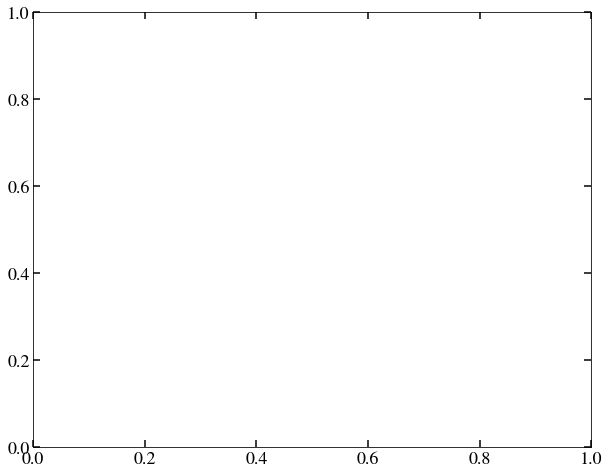

In [9]:
fig_cob, ax_cob = plt.subplots(figsize=(10, 8))

waves_ebl = np.logspace(-1, 3, num=500)
freq_array_ebl = np.log10(3e8 / (waves_ebl * 1e-6))

for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ebl_class.ebl_ssp_calculation(config_data['ssp_models'][key])

    ax_cob.plot(waves_ebl, ebl_class.ebl_ssp_spline(
        waves_ebl, 0.),
                linestyle='-', color=colors[nkey % len(colors)],
                lw=3,
                # markersize=16, marker=markers[nkey]
                )

# We introduce the Finke22 and CUBA splines from ebltable
ebl = {}
for m in EBL.get_models():
    ebl[m] = EBL.readmodel(m)
nuInu = {}
for m, e in ebl.items():
    nuInu[m] = e.ebl_array(np.array([0.]), waves_ebl)
spline_finke = UnivariateSpline(waves_ebl, nuInu['finke2022'], s=0, k=1)
spline_cuba = UnivariateSpline(waves_ebl, nuInu['cuba'], s=0, k=1)
ax_cob.plot(waves_ebl, spline_finke(waves_ebl),
            c='orange', label='Finke22 model A')
ax_cob.plot(waves_ebl, spline_cuba(waves_ebl),
            c='fuchsia', label='CUBA')

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel(r'$\nu I_{\nu}$ (nW / m$^2$ sr)')

legend22 = plt.legend()
legend33 = ax_cob.legend([plt.Line2D([], [], linewidth=2, linestyle='-',
                                     color=colors[i])
                          for i in range(len(config_data['ssp_models']))],
                         [config_data['ssp_models'][key]['name']
                          for key in config_data['ssp_models']],
                         title=r'SSP models',  # bbox_to_anchor=(1.04, 0.1),
                         loc=3
                         )

ax_cob.add_artist(legend22)
ax_cob.add_artist(legend33)


import_cb_data(plot_measurs=True, ax1=ax_cob, lambda_max_total=1000)

plt.xlim([.1, 1000])
plt.ylim(1e-2, 100)

## Writing the EBL models to txt files
Creates a file containing the values for wavelength, redshift and EBL values, 
of dimensions (n+1) x (m+1). This file is compatible with the package ebltable, serving as an input to calculate optical depths.

The zeroth column contains the n wavelength values in mu meters.

The first row contains the m redshift values.

The remaining values (n x m) are the EBL photon density values in nW / m$^2$ sr.

The entry [0,0] is empty.

In [ ]:
ebl_class.logging_prints = False

for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ebl_class.ebl_ssp_calculation(config_data['ssp_models'][key])
    ebl_class.write_ebl_to_ascii(output_path=input_file_dir, name=key)